# Pipeline
This is the set up for how each part of this project will fit together as a whole. Ideally this will be lest of a testing ground and more of a demonstration of progress as the automation algorithm comes togetherr.

# Data Prep/ Zephyr Handeling
This section is intended to stand in as a placeholder for the rest of the Zephyr repository. I will do my best to keep it updated to Zephyr's code. Unfortunately, this function is not running in real time yet and is not being run on Zephyr hardware as a part of the Zepher repo. This section puts data into the format it would be in coming directly from zephyr.

Note: Check for scripts/detection pushes frequently, specifically for parse_selection and reduce_xarray changes, especially on output formats and types.

In [1]:
import glob # A common system tool for finding and parsing files 
data_dir = './rti_examples' # The name of the folder with the files 

In [2]:
import pickle # For loading files

file_name = 'RTI_zephyrtx3_zephyrrx2_1678326201_15s.rti' #Example RTI data with single plane
with open(f'{data_dir}/{file_name}', "rb") as f:
        rti_xarray = pickle.load(f)

In [3]:
words = file_name.split('_')
tof=words[3] #Determine aooroximate time flight is above colorado
sample_time=words[4] #Legnth of sample in seconds
flight_time_info=[tof,sample_time]

In [4]:
import numpy as np 
import matplotlib.pyplot as plt # Plotting 
from matplotlib.ticker import MaxNLocator

# RTI diagram
rti_array = rti_xarray.values[:, 0, :250, :]
#fig, ax = plt.subplots(1, 1, figsize=(14, 7), layout='constrained')
rti_for_plot = np.abs(rti_array.mean(0))  # Collapse Doppler Dimension, mean across channels


(750000, 1)


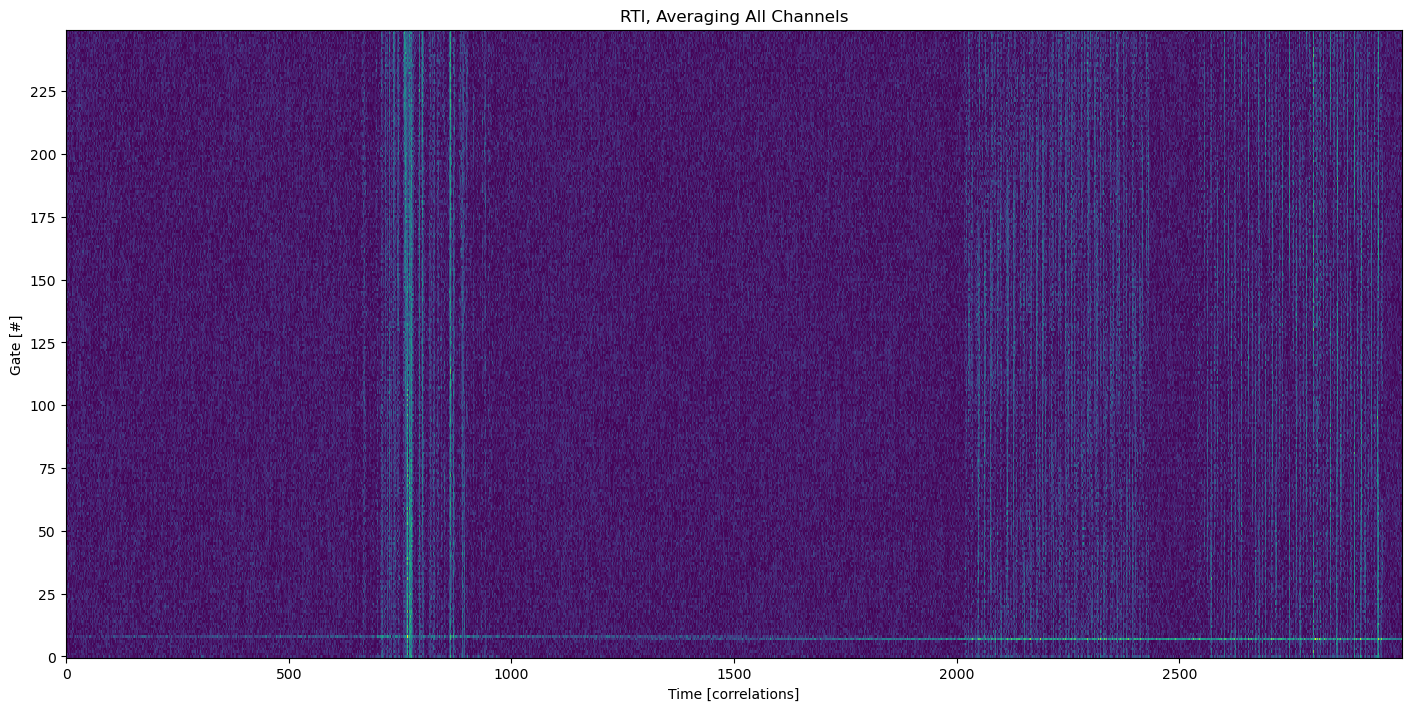

In [5]:
from sklearn.decomposition import PCA

# Performing PCA 
n_ch, n_gates, n_times = rti_array.shape
X = np.moveaxis(rti_array, 0, -1).reshape(-1, n_ch)
X = abs(X)
pca = PCA(n_components=1)
pca.fit(X)
rti_PCA = pca.fit_transform(X)
print(rti_PCA.shape)
rti_PCA = np.reshape(rti_PCA, (n_gates, n_times, 1)).squeeze()

# Plotting 
fig, ax = plt.subplots(1, 1, figsize=(14, 7), layout='constrained')
pca_for_plot = np.abs(rti_PCA[:, :])
ax.imshow(pca_for_plot, origin='lower', aspect='auto', interpolation='none', extent=None)
ax.set_xlabel('Time [correlations]')
ax.set_ylabel('Gate [#]')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title('RTI, Averaging All Channels')
plt.show()

In [6]:

def parse_selection(selection):
    """
    Parse selection for slices or ranges, with support for 'all' and specific indices or ranges.

    Parameters:
    - selection: Can be 'all', a string for channel names, or a list of indices.
    """
    # If selection is "all", return a slice that selects everything
    if isinstance(selection, str) and selection == "all":
        return slice(None)  # Select all elements
    
    # If selection is a string like "120:-1", handle as a slice
    elif isinstance(selection, str) and ":" in selection:
        try:
            return slice(*map(lambda x: int(x) if x.strip() else None, selection.split(":")))
        except ValueError as e:
            raise ValueError(f"Invalid slice string: '{selection}'. Error: {e}")
    
    # If selection is a list or array of values, return it as-is
    elif isinstance(selection, (list, np.ndarray)):
        return selection
    
    else:
        raise ValueError(f"Invalid selection format: '{selection}'.")

def reduce_xarray(xarray_in, dim_operations, value_agg_func=np.abs):
    """
    Reduces the RTI data based on the provided dimension operations (aggregation, selection).
    
    Parameters:
    - dim_operations (dict): Specifies "agg_func" and "selection" for each dimension.
        dim_operations = {
            "tx_rx_channel_pair": {"agg_func": None, "selection": "all"},  # Select polarimetric channels
            "doppler_hz": {"agg_func": None, "selection": [0]},  # Slice specific range
            "gate": {"agg_func": None, "selection": "all"},  # No aggregation
            "time": {"agg_func": None, "selection": "all"}  # Median over specific time slice
            }
    - value_agg_func (callable): Function to transform the data (e.g., np.abs, np.angle).
    
    Returns:
    - reduced_data (numpy.ndarray): Reduced data (2D or 3D) ready for plotting.
    """
    xarray_out = xarray_in.copy()
    xarray_out.attrs =  xarray_in.attrs.copy()
    
    # Apply operations for each dimension
    for dim, operations in dim_operations.items():
        if dim not in xarray_out.dims:
            raise ValueError(f"Dimension '{dim}' not found in data.")

        # Apply selection
        selection = operations.get("selection", "all")
        if dim == "tx_rx_channel_pair" and selection == "polarimetric":
            polarimetric_values = xarray_out.coords['polarimetric_channel'].values
            desired_channels = polarimetric_values[polarimetric_values != None]
            mask = np.isin(polarimetric_values, desired_channels)
            xarray_out = xarray_out.sel(tx_rx_channel_pair=mask)
        else:
            parsed_selection = parse_selection(selection)
            xarray_out = xarray_out.sel({dim: parsed_selection})

        # Apply aggregation if specified
        agg_func = operations.get("agg_func", None)
        if agg_func is not None:
            if not callable(agg_func):
                raise ValueError(f"Aggregation function for '{dim}' must be callable or None.")
            xarray_out = xarray_out.reduce(agg_func, dim=dim, keep_attrs=True)

    # Apply value aggregation function (e.g., np.abs, np.angle)
    if value_agg_func is not None:
        if not callable(value_agg_func):
            raise ValueError("value_agg_func must be a callable function.")
        xarray_out = value_agg_func(xarray_out)
    
    # Modify metadata attributes
    if value_agg_func is not None:
        if 'units' in xarray_out.attrs:
            xarray_out.attrs['units'] = f'{xarray_out.attrs["units"]} ({value_agg_func.__name__})'
        else:
            xarray_out.attrs['units'] = value_agg_func.__name__

    # Return reduced data (converted to numpy array)
    return np.squeeze(xarray_out)
            
'''
save_xarray_to_hdf5(cev_xarray, 'test3.cev')
cev_xarray_loaded = load_xarray_from_hdf5('test3.cev')
cev_xarray_loaded
'''


"\nsave_xarray_to_hdf5(cev_xarray, 'test3.cev')\ncev_xarray_loaded = load_xarray_from_hdf5('test3.cev')\ncev_xarray_loaded\n"

In [7]:
dim_operations = {
                    "tx_rx_channel_pair": {"agg_func": np.std, "selection": "all"},
                    "doppler_hz": {"agg_func": None, "selection": [0]}}
rti_for_det = reduce_xarray(rti_xarray, dim_operations, value_agg_func=np.abs) #Set up Data in the same format as in repository

# Plane Detection Algorithm

In [8]:
from Function_Storage.Plane_Detection import *
import pandas as pd

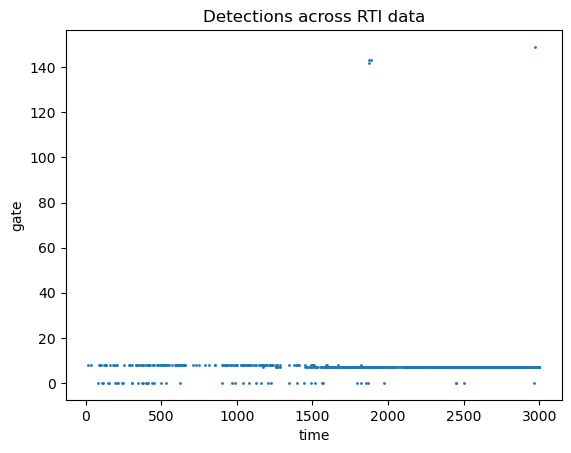

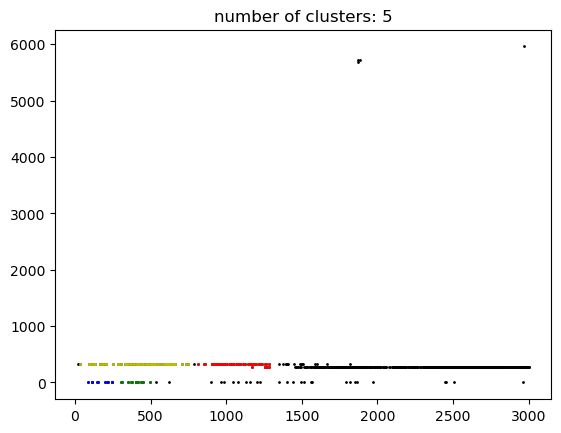

In [9]:
detections,img,ditc_proporties,peak_1D_idx=detect_plane(rti_for_det,0,{},['plot_detections','DBSCAN'],flight_time_info)

In [10]:
ditc_proporties

[{'sample_time:': '1678326201', 'sample_legnth': '15s.rti'},
 {'plane_number': 0,
  'max_time': 750,
  'min_time': 37,
  'max_gate': 8.0,
  'min_gate': 8.0},
 {'plane_number': 1,
  'max_time': 246,
  'min_time': 85,
  'max_gate': 0.0,
  'min_gate': 0.0},
 {'plane_number': 2,
  'max_time': 497,
  'min_time': 307,
  'max_gate': 0.0,
  'min_gate': 0.0},
 {'plane_number': 3,
  'max_time': 1284,
  'min_time': 814,
  'max_gate': 8.0,
  'min_gate': 7.0},
 {'plane_number': 4,
  'max_time': 3000,
  'min_time': 1347,
  'max_gate': 8.0,
  'min_gate': 7.0}]

In [11]:
df = pd.DataFrame({'time': np.arange(0, 3001)})

In [13]:
for x in ditc_proporties[1:]:
    if x['max_time']-x['min_time']>300:
        a_col_str=f"det{x['plane_number']}_a"
        b_col_str=f"det{x['plane_number']}_b"
        df[a_col_str]=x['max_gate']
        df[b_col_str]=x['min_gate']
df

,time,det0_a,det0_b,det3_a,det3_b,det4_a,det4_b
0,0,8.0,8.0,8.0,7.0,8.0,7.0
1,1,8.0,8.0,8.0,7.0,8.0,7.0
2,2,8.0,8.0,8.0,7.0,8.0,7.0
3,3,8.0,8.0,8.0,7.0,8.0,7.0
4,4,8.0,8.0,8.0,7.0,8.0,7.0
...,...,...,...,...,...,...,...
2996,2996,8.0,8.0,8.0,7.0,8.0,7.0
2997,2997,8.0,8.0,8.0,7.0,8.0,7.0
2998,2998,8.0,8.0,8.0,7.0,8.0,7.0
2999,2999,8.0,8.0,8.0,7.0,8.0,7.0


# Single Flight Tools

## Set up basic input to Single Flight Tools

In [ ]:
from Function_Storage.Single_Flight_tools import * #Initial Single Flight tools 
from Function_Storage.Flight_Tools_class import * #Single Flight Tools using class system

Reading Single_Flight_tools


In [ ]:
import pandas as pd
df = pd.read_csv('ADS_Bdata/UAL2210_ADSB.csv',names=["Callsign","lat","lon","catagory","onground","timeposition","geoaltitude","time"])
df

,Callsign,lat,lon,catagory,onground,timeposition,geoaltitude,time
0,UAL2210,39.7735,-105.2202,0,False,1754639714,10058.40,1754633565
1,UAL2210,39.7803,-105.1848,0,False,1754639725,10066.02,1754633575
2,UAL2210,39.7791,-105.1912,0,False,1754639723,10066.02,1754633585
3,UAL2210,39.7859,-105.1553,0,False,1754639735,10058.40,1754633595
4,UAL2210,39.7859,-105.1553,0,False,1754639735,10058.40,1754633605
5,UAL2210,39.8026,-105.0682,0,False,1754639765,10058.40,1754633615
6,UAL2210,39.8066,-105.0468,0,False,1754639773,10058.40,1754633625
7,UAL2210,39.8136,-105.0097,0,False,1754639785,10058.40,1754633635
8,UAL2210,39.8197,-104.9778,0,False,1754639796,10058.40,1754633645
9,UAL2210,39.8331,-104.9069,0,False,1754639820,10066.02,1754633655


In [ ]:
tx_latlonalt=[51,-5.5,0]
rx_latlonalt=[52,-10,0]

## use of Single Flight Tools

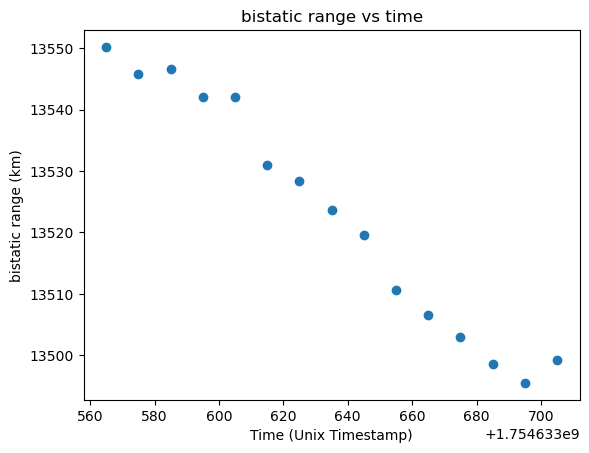

In [ ]:
package=Data_Package(df,tx_latlonalt,rx_latlonalt)
package.name_thing()
package.convertCoords()
package.bistaticrange(True)

In [ ]:
data=package.df

In [ ]:
N=1000
x=np.linspace(package.df['time'][0], package.df['time'][len(package.df)-1], num=N)
package.interpolate(x)
package.df_intermolated

,time,brange
0,1.754634e+09,13550.184175
1,1.754634e+09,13513.088689
2,1.754634e+09,13479.118123
3,1.754634e+09,13448.106559
4,1.754634e+09,13419.894561
...,...,...
995,1.754634e+09,13401.031611
996,1.754634e+09,13422.239715
997,1.754634e+09,13445.596653
998,1.754634e+09,13471.227779


In [ ]:
import numpy as np
from scipy.interpolate import BarycentricInterpolator

# Define data points
x = np.array([-1, 0, 1])
y = np.array([1, 0, 1])

# Create the interpolator
poly = BarycentricInterpolator(x, y)

# Evaluate at a new point
x_new = 0.5
y_new = poly(x_new)

print(f"The interpolated value at x={x_new} is y={y_new}")

The interpolated value at x=0.5 is y=0.25
